# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

In [7]:
def getdata(filename, skiprows, delimiter, decimal):
    #load data from a file
    data = pd.read_csv(filename, delimiter=delimiter, decimal=decimal, skiprows=skiprows).to_numpy()
    x = data[:, 0]
    y = data[:, 1]
    return x, y

def f_lin(x, a, b):
    #input your function here
    return a*x + b

def curve_fit_function(x, y, p0):
    #fit your function to the data
    popt, pcov = curve_fit(f_lin, x, y, p0=p0)
    pcov = np.sqrt(np.diag(pcov))
    print(f"a = {popt[0]} ± {pcov[0]}")
    print(f"b = {popt[1]} ± {pcov[1]}")
    return popt

a = 1.3399999986376043 ± 0.020000000193174734
b = 21.24000000272479 ± 0.048989794368834945


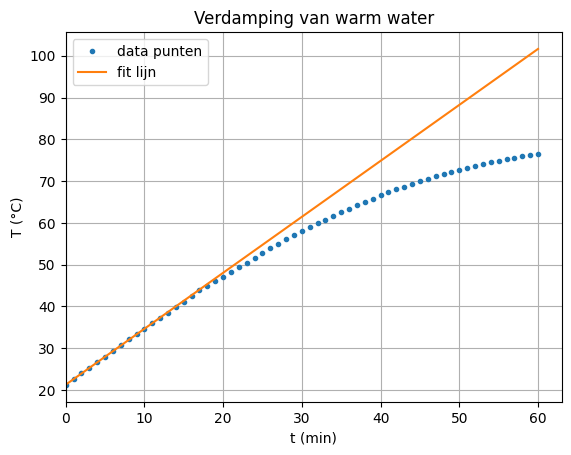

In [8]:
#data uit bestand inladen
filename = "tempmetingen.csv"
skiprows = 0
delimiter = ";"
decimal = "."
x, y = getdata(filename, skiprows, delimiter, decimal)

#fitten op de eerste paar punten omdat hier een linair verband 
#omdat er nog weinig of geen warmte verloren is gegaan aan de omgeving
x_fit = x[0:5]
y_fit = y[0:5]
popt = curve_fit_function(x_fit, y_fit, p0 = [1.4, x[0]])

#bereken y waarden van de fit functie voor de plot
y_fit = f_lin(x, *popt)

plt.figure()
plt.plot(x, y, '.', label='data punten')
plt.plot(x, y_fit, '-', label='fit lijn')

plt.xlabel('t (min)')
plt.ylabel('T (°C)')
plt.title('Verdamping van warm water')

plt.xlim(0)
plt.grid()
plt.legend()

plt.savefig("Figures/Verdamping1.png", dpi=450)
plt.show()


In [16]:
#de aannames:
"""
het water is perfect geisoleerd
het water is homogeen van temperatuur
Het bakje warm maar een kleie hoeveelheid op
"""

c_water = 4.186 # Kj/kg K
E_verdamping = 2256 # KJ/Kg

m_water = (1292.9 - 820.8) * 1e-3 # kg
m_verdampt = (1292.9 - 1274.9) * 1e-3 # kg

#totale energie volgens de fit als niks verdampt zou zijn
delta_T = max(y_fit) - min(y_fit)
E_literatuur = m_water * c_water * delta_T # KJ
print(E_literatuur)

#totale energie volgens de data als er wel verdamping is
Delta_T = max(y) - min(y)
E_verwarming = m_water * c_water * Delta_T # KJ
E_vaseovergang = m_verdampt * E_verdamping # KJ
E_totaal = E_verwarming + E_vaseovergang
print(E_totaal)

#verschil in energie
E_verschil = E_literatuur - E_totaal
print(E_verschil)

158.88733207845718
150.09006724000002
8.797264838457153


Dit verschil van 8.8 KJ is hoogwaarschijnlijk de enrgie die het bakje heeft opgenomen

voor een perfect experiment zou je een

afgeloten volumme van puur water hebben
dat perfect geidoleerd is waardoor $Q_{uit}$ = 0
en afgesloten zodat het water niet kan verdampen

verder een heet reservior $T_{h}$ dat een constante $Q_{in}$ leverd zodat er een liniear verband ontstaat tussen de temperatuur en tijd
